# Import Libraries and Data Importing


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/comauto_pos.csv")

# Data Exploration

In [ ]:
df.head()

,GRCODE,GRNAME,AccidentYear,DevelopmentYear,DevelopmentLag,IncurLoss_C,CumPaidLoss_C,BulkLoss_C,EarnedPremDIR_C,EarnedPremCeded_C,EarnedPremNet_C,Single,PostedReserve97_C
0,266,Public Underwriters Grp,1988,1988,1,0,0,0,0,0,0,0,932
1,266,Public Underwriters Grp,1988,1989,2,0,0,0,0,0,0,0,932
2,266,Public Underwriters Grp,1988,1990,3,0,0,0,0,0,0,0,932
3,266,Public Underwriters Grp,1988,1991,4,0,0,0,0,0,0,0,932
4,266,Public Underwriters Grp,1988,1992,5,0,0,0,0,0,0,0,932


In [ ]:
df['GRCODE'].unique()

array([  266,   337,   353,   388,   460,   620,   655,   671,   715,
         833,   965,  1066,  1090,  1279,  1538,  1716,  1767,  2003,
        2135,  2143,  2208,  2569,  2623,  2712,  3131,  3240,  3492,
        4839,  5185,  5320,  5690,  5940,  6408,  6459,  6777,  6807,
        6947,  7080,  8079,  8281,  8427,  8559,  8672,  9466, 10019,
       10022, 10048, 10074, 10100, 10308, 10561, 10790, 10859, 10894,
       11037, 11118, 11126, 11150, 11231, 11460, 12866, 13420, 13439,
       13501, 13528, 13587, 13641, 13889, 13943, 14044, 14176, 14257,
       14311, 14320, 14370, 14508, 14974, 15024, 15199, 15407, 15792,
       15911, 15997, 16411, 16748, 17299, 17884, 18163, 18309, 18380,
       18538, 18686, 18767, 18791, 19020, 19780, 20451, 20690, 21172,
       21270, 22390, 23574, 23663, 25275, 25950, 26077, 26433, 26797,
       26905, 27022, 27065, 27499, 27955, 27980, 28258, 28436, 28535,
       28550, 28886, 29297, 29378, 29440, 31550, 31810, 32301, 32514,
       32670, 32743,

In [ ]:
df_company = df[df['GRCODE'] == 13587]

# Functions

In [ ]:
##############################
#FUNCTIONS
##############################
def build_triangle(
    df,
    index_col,
    column_col,
    value_col,
    aggfunc="sum"
):
    """
    Builds a triangle from a long-form DataFrame.
    """
    return df.pivot_table(
        index=index_col,
        columns=column_col,
        values=value_col,
        aggfunc=aggfunc
    )

def incremental_to_cumulative(triangle: pd.DataFrame) -> pd.DataFrame:
    """
    Convert incremental loss triangle to cumulative loss triangle.
    Also ensures columns are typed as integers.
    """
    cumulative = triangle.cumsum(axis=1)
    cumulative.columns = cumulative.columns.astype(int)
    return cumulative

def calculate_age_to_age_factors(cumulative_triangle):
    """
    Calculate individual age-to-age factors for every accident year.
    Parameters
    ----------
    cumulative_triangle : pd.DataFrame
        Cumulative loss triangle
    Returns
    -------
    pd.DataFrame
        Age-to-age factor matrix
    """

    factors = pd.DataFrame(index=cumulative_triangle.index)
    for col in range(cumulative_triangle.shape[1] - 1):

        current = cumulative_triangle.iloc[:, col]
        nxt = cumulative_triangle.iloc[:, col + 1]

        factors[f"{col+1}->{col+2}"] = nxt / current

    return factors

def plot_age_to_age(age_to_age_triangle):

    for col in age_to_age_triangle.columns:

        plt.figure(figsize=(8,4))

        plt.plot(
            age_to_age_triangle.index,
            age_to_age_triangle[col],
            marker="o"
        )

        plt.title(f"Age-to-Age Factor {col}")
        plt.xlabel("Accident Year")
        plt.ylabel("Factor")
        plt.grid(True)

        plt.show()

def calculate_average_factors(age_to_age_triangle):

    results = {}

    for col in age_to_age_triangle.columns:

        factors = age_to_age_triangle[col].dropna()

        simple = factors.mean()

        geometric = np.prod(factors) ** (1 / len(factors))

        if len(factors) >= 3:
            medial = (
                factors.sort_values()
                .iloc[1:-1]
                .mean()
            )
        else:
            medial = simple

        results[col] = {
            "Simple": simple,
            "Geometric": geometric,
            "Medial": medial
        }

    return pd.DataFrame(results)

def plot_average_factors(avg_factors):

    plt.figure(figsize=(10,5))

    for avg_type in avg_factors.index:

        plt.plot(
            avg_factors.columns,
            avg_factors.loc[avg_type],
            marker='o',
            label=avg_type
        )

    plt.xlabel("Development Period")
    plt.ylabel("Factor")
    plt.title("Average Development Factors")
    plt.legend()
    plt.grid(True)

    plt.show()

def select_ldfs(avg_factors):

    print("Select LDF Method:")
    print("1. Simple Average")
    print("2. Geometric Average")
    print("3. Medial Average")

    choice = input("Enter choice (1-3): ")

    method_map = {
        "1": "Simple",
        "2": "Geometric",
        "3": "Medial"
    }

    selected_ldfs = avg_factors.loc[method_map[choice]].copy()

    tail_input = input(
        "Enter Tail Factor (press Enter for 1.0): "
    )

    tail_factor = (
        float(tail_input)
        if tail_input.strip()
        else 1.0
    )

    selected_ldfs["Tail"] = tail_factor

    return selected_ldfs

def calculate_cdfs(selected_ldfs):

    cdfs = []

    factors = selected_ldfs.values

    for i in range(len(factors)):
        cdfs.append(np.prod(factors[i:]))

    return pd.Series(cdfs)

def project_ultimates(triangle, cdfs):

    cdfs = cdfs.copy()
    cdfs.index = triangle.columns

    results = []

    for ay in triangle.index:

        row = triangle.loc[ay].dropna()

        latest_age = row.index[-1]
        latest_value = row.iloc[-1]

        cdf = cdfs.loc[latest_age]

        ultimate = latest_value * cdf

        results.append({
            "AccidentYear": ay,
            "LatestAge": latest_age,
            "LatestValue": latest_value,
            "CDF": cdf,
            "Ultimate": ultimate
        })

    return pd.DataFrame(results)

def calculate_reserves(ultimate_df):

    reserve_df = ultimate_df.copy()

    reserve_df["Reserve"] = (
        reserve_df["Ultimate"]
        - reserve_df["LatestValue"]
    )

    return reserve_df

def calculate_total_reserve(reserve_df):

    total_reserve = reserve_df["Reserve"].sum()
    return total_reserve

# Data Preparation


In [ ]:
paid = build_triangle(df_company,index_col ='AccidentYear',column_col = 'DevelopmentLag',value_col='CumPaidLoss_C',aggfunc="sum" )
incurred = build_triangle(df_company,index_col ='AccidentYear',column_col = 'DevelopmentLag',value_col='IncurLoss_C',aggfunc="sum" )

This is a fully squared triangle from CAS. So, this is being converted back to a triangular format

In [ ]:
df_masked=df[df['DevelopmentYear']<=1997]
df_masked_company = df_masked[df_masked['GRCODE'] == 13587]
paid_masked = build_triangle(df_masked_company,index_col ='AccidentYear',column_col = 'DevelopmentLag',value_col='CumPaidLoss_C',aggfunc="sum" )
incurred_masked = build_triangle(df_masked_company,index_col ='AccidentYear',column_col = 'DevelopmentLag',value_col='IncurLoss_C',aggfunc="sum" )

In [ ]:
#plot_age_to_age(paid_age_to_age_factors)
#plot_age_to_age(incurred_age_to_age_factors)

# One final function for full Chain Ladder Method

In [ ]:
def run_chain_ladder(triangle):

    # Age-to-Age Factors
    age_to_age = calculate_age_to_age_factors(triangle)

    # Diagnostics
    plot_age_to_age(age_to_age)

    # Average Factors
    avg_ldfs = calculate_average_factors(age_to_age)

    print("\nAverage LDFs")
    display(avg_ldfs)

    # Average Plot
    plot_average_factors(avg_ldfs)

    # Select LDFs
    selected_ldfs = select_ldfs(avg_ldfs)

    print("\nSelected LDFs")
    display(selected_ldfs)

    # CDFs
    cdfs = calculate_cdfs(selected_ldfs)

    print("\nCDFs")
    display(cdfs)

    # Ultimate Projection
    ultimate_df = project_ultimates(
        triangle,
        cdfs
    )

    print("\nUltimate Projection")
    display(ultimate_df)

    # Reserves
    reserve_df = calculate_reserves(
        ultimate_df
    )

    print("\nReserve Projection")
    display(reserve_df)

    # Total Reserve
    total_reserve = calculate_total_reserve(
        reserve_df
    )

    print(f"\nTotal Reserve = {total_reserve:,.2f}")

    return {
        "age_to_age": age_to_age,
        "avg_ldfs": avg_ldfs,
        "selected_ldfs": selected_ldfs,
        "cdfs": cdfs,
        "ultimate_df": ultimate_df,
        "reserve_df": reserve_df,
        "total_reserve": total_reserve
    }

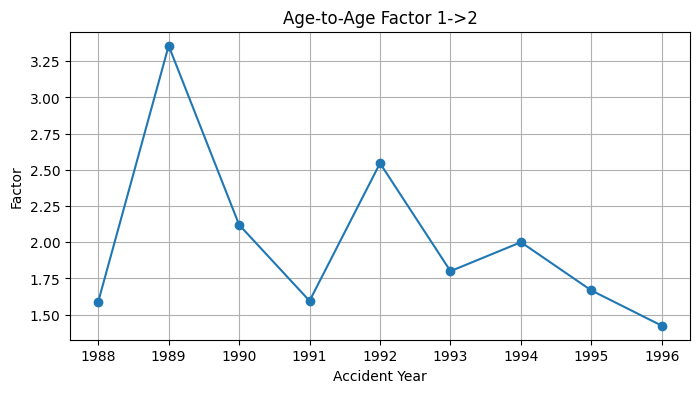

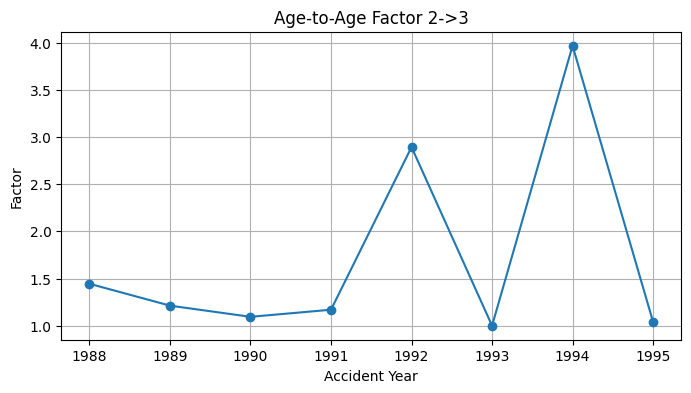

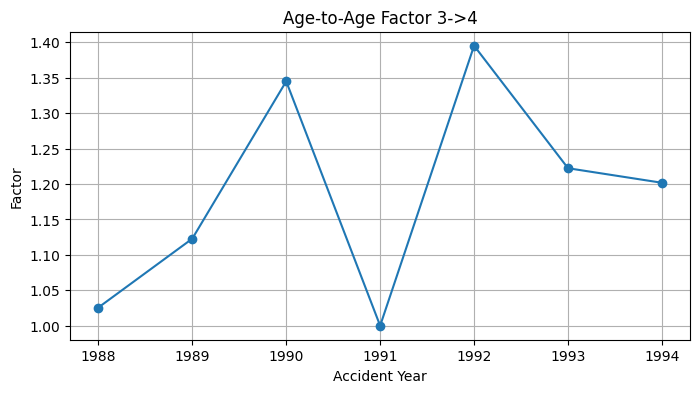

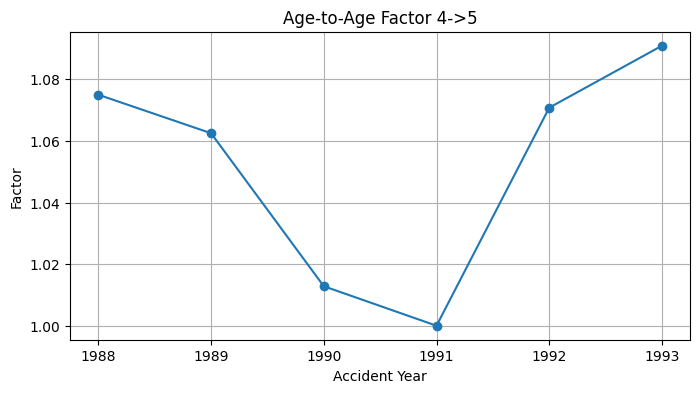

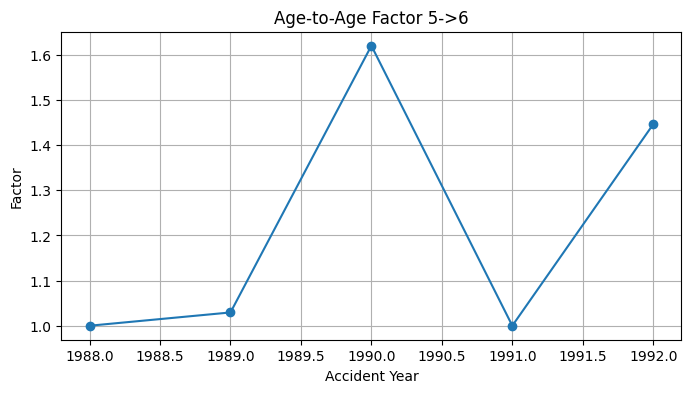

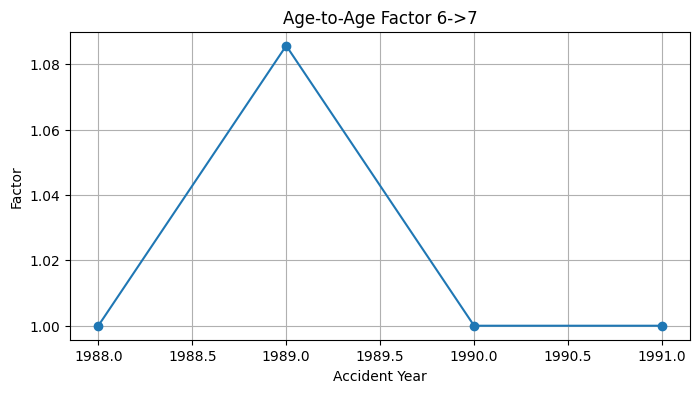

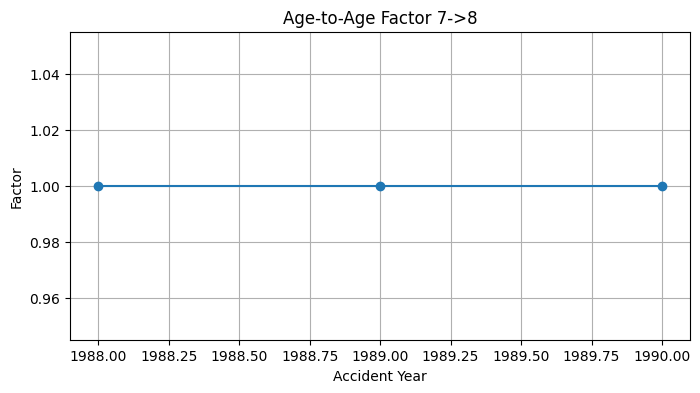

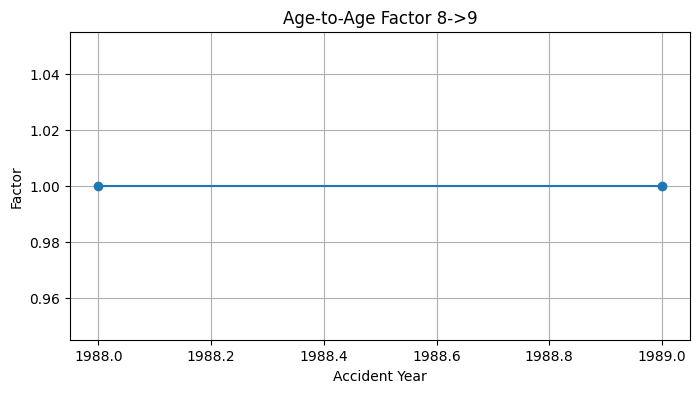

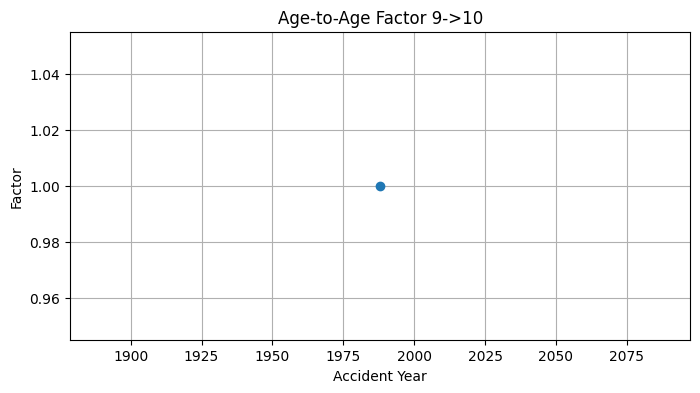


Average LDFs


,1->2,2->3,3->4,4->5,5->6,6->7,7->8,8->9,9->10
Simple,2.010575,1.727571,1.187463,1.052004,1.219189,1.021429,1.0,1.0,1.0
Geometric,1.941390,1.508088,1.179350,1.051464,1.192573,1.020772,1.0,1.0,1.0
Medial,1.902136,1.475650,1.183436,1.055279,1.158564,1.000000,1.0,1.0,1.0


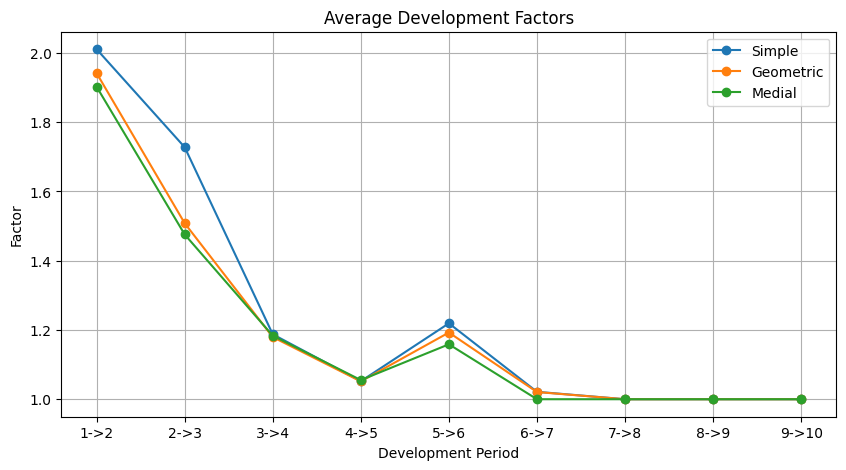

Select LDF Method:
1. Simple Average
2. Geometric Average
3. Medial Average
Enter choice (1-3): 2
Enter Tail Factor (press Enter for 1.0): 

Selected LDFs


,Geometric
1->2,1.941390
2->3,1.508088
3->4,1.179350
4->5,1.051464
5->6,1.192573
6->7,1.020772
7->8,1.000000
8->9,1.000000
9->10,1.000000
Tail,1.000000



CDFs


,0
0,4.419675
1,2.276552
2,1.509562
3,1.279994
4,1.217345
5,1.020772
6,1.000000
7,1.000000
8,1.000000
9,1.000000



Ultimate Projection


,AccidentYear,LatestAge,LatestValue,CDF,Ultimate
0,1988,10,86.0,1.000000,86.000000
1,1989,9,76.0,1.000000,76.000000
2,1990,8,128.0,1.000000,128.000000
3,1991,7,69.0,1.000000,69.000000
4,1992,6,175.0,1.020772,178.635157
5,1993,5,24.0,1.217345,29.216290
6,1994,4,143.0,1.279994,183.039193
7,1995,3,26.0,1.509562,39.248605
8,1996,2,37.0,2.276552,84.232413
9,1997,1,25.0,4.419675,110.491887



Reserve Projection


,AccidentYear,LatestAge,LatestValue,CDF,Ultimate,Reserve
0,1988,10,86.0,1.000000,86.000000,0.000000
1,1989,9,76.0,1.000000,76.000000,0.000000
2,1990,8,128.0,1.000000,128.000000,0.000000
3,1991,7,69.0,1.000000,69.000000,0.000000
4,1992,6,175.0,1.020772,178.635157,3.635157
5,1993,5,24.0,1.217345,29.216290,5.216290
6,1994,4,143.0,1.279994,183.039193,40.039193
7,1995,3,26.0,1.509562,39.248605,13.248605
8,1996,2,37.0,2.276552,84.232413,47.232413
9,1997,1,25.0,4.419675,110.491887,85.491887



Total Reserve = 194.86


In [ ]:
paid_results = run_chain_ladder(paid_masked)

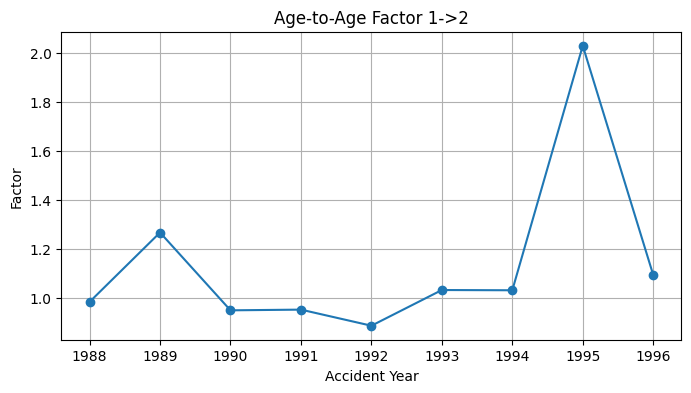

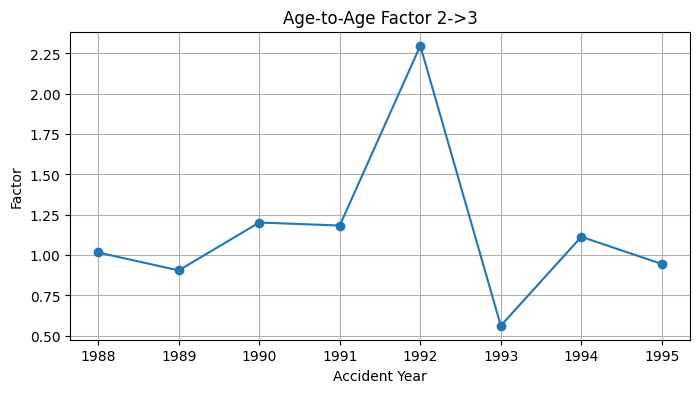

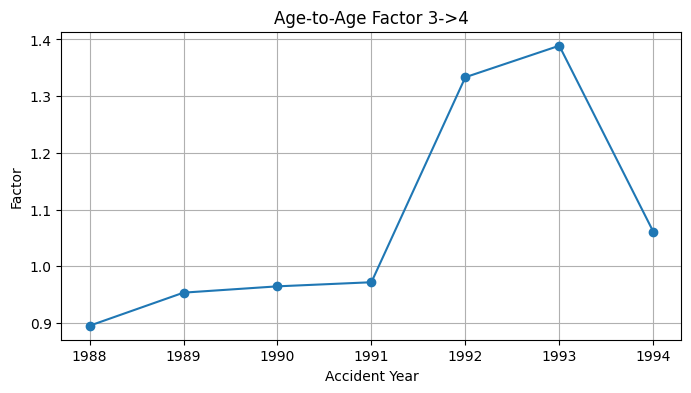

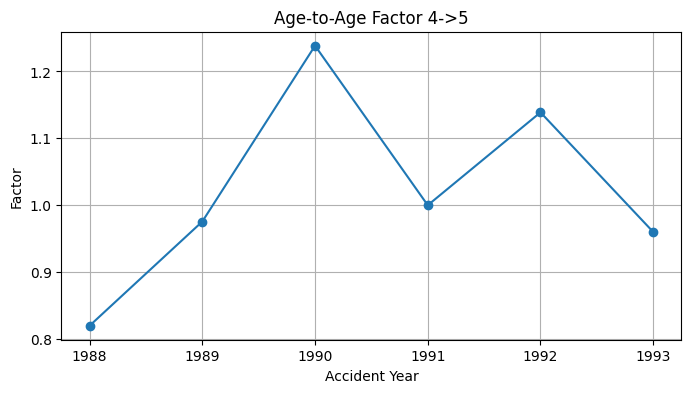

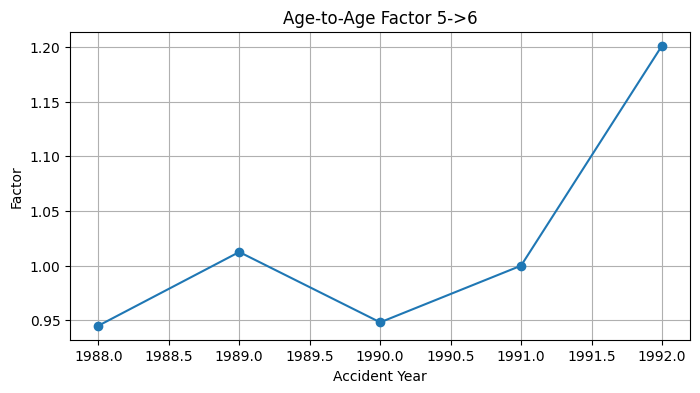

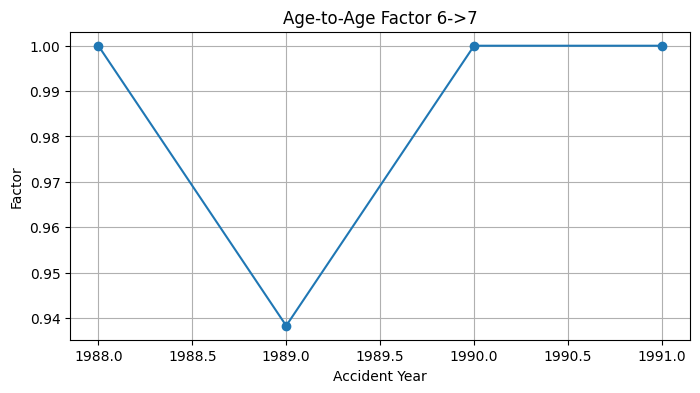

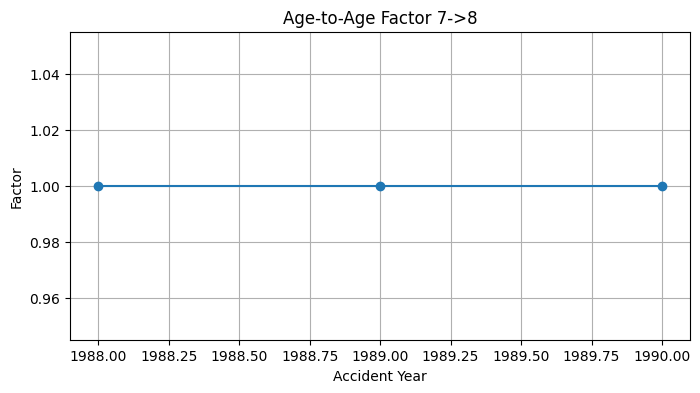

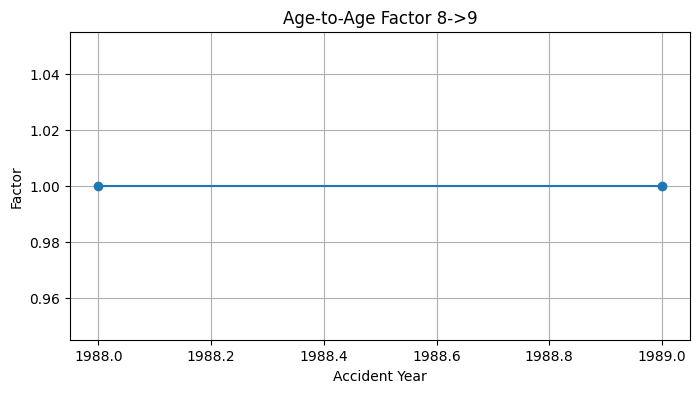

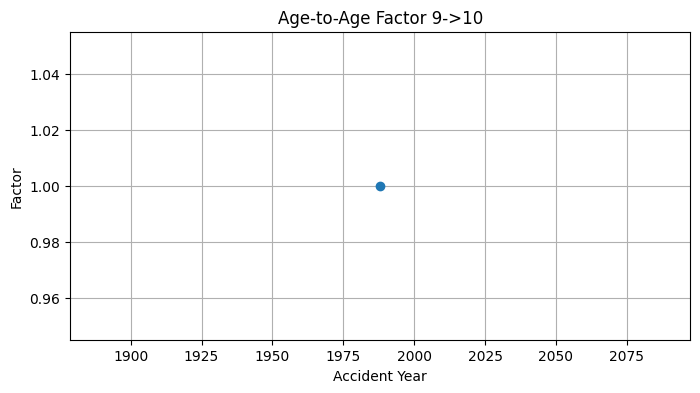


Average LDFs


,1->2,2->3,3->4,4->5,5->6,6->7,7->8,8->9,9->10
Simple,1.136027,1.153291,1.081218,1.022142,1.021385,0.984568,1.0,1.0,1.0
Geometric,1.100079,1.074797,1.066796,1.013388,1.017349,0.984197,1.0,1.0,1.0
Medial,1.044239,1.060993,1.056896,1.018625,0.986883,1.000000,1.0,1.0,1.0


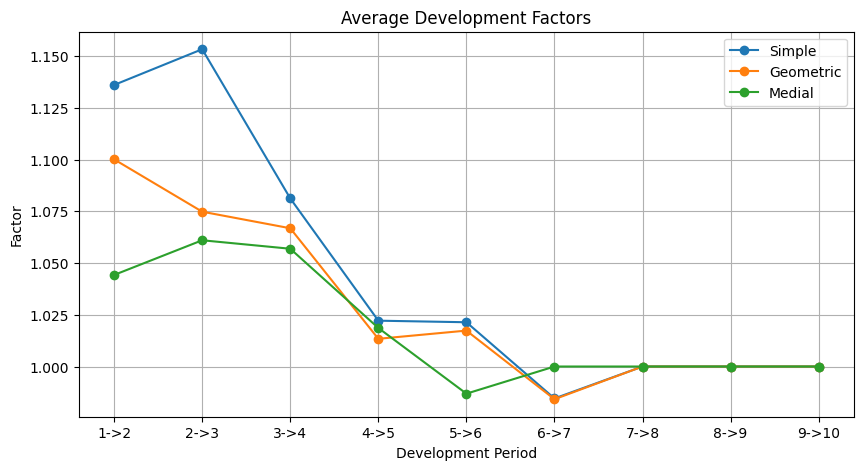

Select LDF Method:
1. Simple Average
2. Geometric Average
3. Medial Average
Enter choice (1-3): 2
Enter Tail Factor (press Enter for 1.0): 

Selected LDFs


,Geometric
1->2,1.100079
2->3,1.074797
3->4,1.066796
4->5,1.013388
5->6,1.017349
6->7,0.984197
7->8,1.000000
8->9,1.000000
9->10,1.000000
Tail,1.000000



CDFs


,0
0,1.279852
1,1.163418
2,1.082454
3,1.014677
4,1.001272
5,0.984197
6,1.000000
7,1.000000
8,1.000000
9,1.000000



Ultimate Projection


,AccidentYear,LatestAge,LatestValue,CDF,Ultimate
0,1988,10,86.0,1.000000,86.000000
1,1989,9,76.0,1.000000,76.000000
2,1990,8,128.0,1.000000,128.000000
3,1991,7,69.0,1.000000,69.000000
4,1992,6,197.0,0.984197,193.886857
5,1993,5,24.0,1.001272,24.030539
6,1994,4,156.0,1.014677,158.289683
7,1995,3,69.0,1.082454,74.689300
8,1996,2,105.0,1.163418,122.158911
9,1997,1,134.0,1.279852,171.500230



Reserve Projection


,AccidentYear,LatestAge,LatestValue,CDF,Ultimate,Reserve
0,1988,10,86.0,1.000000,86.000000,0.000000
1,1989,9,76.0,1.000000,76.000000,0.000000
2,1990,8,128.0,1.000000,128.000000,0.000000
3,1991,7,69.0,1.000000,69.000000,0.000000
4,1992,6,197.0,0.984197,193.886857,-3.113143
5,1993,5,24.0,1.001272,24.030539,0.030539
6,1994,4,156.0,1.014677,158.289683,2.289683
7,1995,3,69.0,1.082454,74.689300,5.689300
8,1996,2,105.0,1.163418,122.158911,17.158911
9,1997,1,134.0,1.279852,171.500230,37.500230



Total Reserve = 59.56


In [ ]:
incurred_results = run_chain_ladder(incurred_masked)

Reserve = Ultimate Loass - Paid Losses to data  
  

IBNR = Incurred Loass - Incurred Loss To Date  
  
  
Incurred = Paid + Case Outstanding
  
Reserve = Case Outstanding + IBNR  
  
| Method                | Output                      |
| --------------------- | --------------------------- |
| Paid Chain Ladder     | Total Unpaid Claim Estimate |
| Incurred Chain Ladder | IBNR Estimate               |


# Comparing with Actual Data

In [ ]:
def get_actual_ultimates(full_triangle):

    actual = pd.DataFrame({
        "AccidentYear": full_triangle.index,
        "ActualUltimate": full_triangle.iloc[:, -1]
    })

    return actual

def compare_ultimates(predicted_df, full_triangle):

    comparison = predicted_df.copy()

    # Actual ultimate from fully developed CAS triangle
    comparison["ActualUltimate"] = (
        full_triangle.iloc[:, -1].values
    )

    comparison["Error"] = (
        comparison["Ultimate"]
        - comparison["ActualUltimate"]
    )

    comparison["AbsError"] = (
        comparison["Error"].abs()
    )

    comparison["PctError"] = (
        comparison["Error"]
        / comparison["ActualUltimate"]
        * 100
    )

    return comparison

def evaluate_predictions(comparison_df):

    mae = comparison_df["AbsError"].mean()

    rmse = np.sqrt(
        (comparison_df["Error"] ** 2).mean()
    )

    mape = (
        comparison_df["PctError"]
        .abs()
        .mean()
    )

    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [ ]:
paid_comparison = compare_ultimates(
    paid_results["ultimate_df"],
    paid
)

paid_metrics = evaluate_predictions(
    paid_comparison
)

paid_comparison

MAE  : 6.40
RMSE : 11.34
MAPE : 5.34%


,AccidentYear,LatestAge,LatestValue,CDF,Ultimate,ActualUltimate,Error,AbsError,PctError
0,1988,10,86.0,1.000000,86.000000,86,0.000000,0.000000,0.000000
1,1989,9,76.0,1.000000,76.000000,76,0.000000,0.000000,0.000000
2,1990,8,128.0,1.000000,128.000000,128,0.000000,0.000000,0.000000
3,1991,7,69.0,1.000000,69.000000,69,0.000000,0.000000,0.000000
4,1992,6,175.0,1.020772,178.635157,204,-25.364843,25.364843,-12.433746
5,1993,5,24.0,1.217345,29.216290,25,4.216290,4.216290,16.865160
6,1994,4,143.0,1.279994,183.039193,207,-23.960807,23.960807,-11.575269
7,1995,3,26.0,1.509562,39.248605,41,-1.751395,1.751395,-4.271694
8,1996,2,37.0,2.276552,84.232413,82,2.232413,2.232413,2.722454
9,1997,1,25.0,4.419675,110.491887,117,-6.508113,6.508113,-5.562490


In [ ]:
incurred_comparison = compare_ultimates(
    incurred_results["ultimate_df"],
    incurred
)

incurred_metrics = evaluate_predictions(
    incurred_comparison
)

incurred_comparison

MAE  : 18.81
RMSE : 28.62
MAPE : 21.01%


,AccidentYear,LatestAge,LatestValue,CDF,Ultimate,ActualUltimate,Error,AbsError,PctError
0,1988,10,86.0,1.000000,86.000000,86,0.000000,0.000000,0.000000
1,1989,9,76.0,1.000000,76.000000,76,0.000000,0.000000,0.000000
2,1990,8,128.0,1.000000,128.000000,128,0.000000,0.000000,0.000000
3,1991,7,69.0,1.000000,69.000000,69,0.000000,0.000000,0.000000
4,1992,6,197.0,0.984197,193.886857,204,-10.113143,10.113143,-4.957423
5,1993,5,24.0,1.001272,24.030539,25,-0.969461,0.969461,-3.877842
6,1994,4,156.0,1.014677,158.289683,207,-48.710317,48.710317,-23.531554
7,1995,3,69.0,1.082454,74.689300,41,33.689300,33.689300,82.169024
8,1996,2,105.0,1.163418,122.158911,82,40.158911,40.158911,48.974282
9,1997,1,134.0,1.279852,171.500230,117,54.500230,54.500230,46.581393


# Expected Claims Method